## Job Market Analysis

This analysis explores job market trends across roles, platforms, job types, and remote work patterns.  
The goal is to identify where opportunities exist and how work preferences impact demand and salary.

In [1]:
import pandas as pd
# import sys
# import os

# sys.path.append(os.path.abspath(".."))

#from src.skills_processing import create_skills_df

df = pd.read_pickle("../data/processed/cleaned_jobs.pkl")
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_id
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",[Work Nearby],Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,[],{},J-e02c886264ce
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[nosql, power bi, python, r, sql, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",[LinkedIn],Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[airflow, azure, c#, dax, docker, jenkins, kub...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",J-c8afb754b830
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",[Diversity.com],Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[aws, c++, java, keras, matlab, python, pytorc...","{'cloud': ['aws'], 'libraries': ['keras', 'pyt...",J-6b595ba75824
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",[Clearance Jobs],Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[ansible, aws, bash, git, gitlab, jenkins, ora...","{'cloud': ['aws', 'oracle'], 'other': ['ansibl...",J-88bb30c3cf7d


## 1. Job Type (Schedule) Analysis

1.1 Overall Job Type Distribution

Most job postings are full-time, indicating strong preference for stable employment structures.

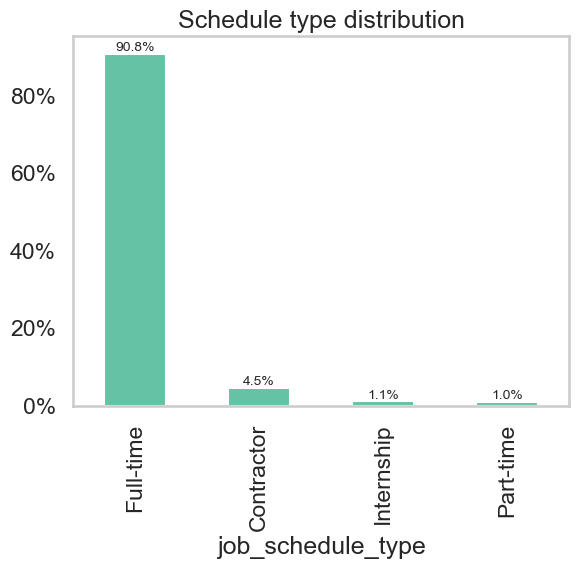

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

#df['job_schedule_type'].value_counts().head(4).plot(kind='bar', title='Schedule type distribution')
ax = df['job_schedule_type'].value_counts(normalize=True).head(4).plot(
    kind='bar',
    title='Schedule type distribution'
)

plt.grid(False)

# Add % labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height*100:.1f}%',          # convert to %
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=10
    )

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

plt.show()

1.2 Non Full-time Roles Breakdown

Excluding full-time roles, contract positions dominate, while internships and part-time roles remain limited.

In [3]:
top_schedule_types = df['job_schedule_type'].value_counts().head(4)
top_schedule_types

job_schedule_type
Full-time     700926
Contractor     34761
Internship      8737
Part-time       7869
Name: count, dtype: int64

In [4]:
role_jobtype = pd.crosstab(
    df['job_title_short'],
    df['job_schedule_type'],
    normalize='index'   # 👈 THIS is key
)
role_jobtype

job_schedule_type,Contractor,Contractor and Full-time,Contractor and Internship,Contractor and Part-time,Contractor and Per diem,Contractor and Temp work,"Contractor, Temp work, and Internship",Full-time,Full-time and Contractor,Full-time and Internship,...,"Part-time, Contractor, and Temp work","Part-time, Internship, and Volunteer","Part-time, Temp work, and Internship",Pekerjaan tetap,Per diem,Temp work,Temp work and Full-time,Temp work and Internship,"Temp work, Full-time, and Part-time",Volunteer
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,0.035424,0.000000,0.000126,0.000000,0.000021,0.002094,0.000000,0.922473,0.003015,0.002282,...,0.000021,0.000000,0.000021,0.000105,0.000000,0.003161,0.000000,0.000251,0.000000,0.000063
Cloud Engineer,0.026785,0.000000,0.000082,0.000000,0.000000,0.001479,0.000000,0.947170,0.003204,0.000822,...,0.000000,0.000000,0.000000,0.000082,0.000000,0.003533,0.000000,0.000000,0.000000,0.000000
Data Analyst,0.052268,0.000005,0.000042,0.000000,0.000010,0.002870,0.000005,0.882493,0.003351,0.004324,...,0.000031,0.000000,0.000026,0.000026,0.000078,0.004036,0.000000,0.000465,0.000000,0.000131
Data Engineer,0.062594,0.000000,0.000033,0.000016,0.000000,0.004041,0.000000,0.899943,0.003425,0.001980,...,0.000033,0.000000,0.000011,0.000142,0.000005,0.002498,0.000000,0.000125,0.000005,0.000027
Data Scientist,0.036161,0.000000,0.000094,0.000000,0.000006,0.003435,0.000006,0.900759,0.002635,0.005477,...,0.000035,0.000006,0.000018,0.000018,0.000018,0.002577,0.000000,0.000482,0.000000,0.000088
Machine Learning Engineer,0.029467,0.000000,0.000072,0.000000,0.000000,0.002305,0.000072,0.932205,0.002810,0.002666,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.001945,0.000000,0.000000,0.000000,0.000072
Senior Data Analyst,0.033675,0.000000,0.000000,0.000000,0.000000,0.001743,0.000000,0.941609,0.002475,0.000035,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.001987,0.000000,0.000000,0.000000,0.000035
Senior Data Engineer,0.045238,0.000000,0.000000,0.000000,0.000000,0.002792,0.000000,0.931451,0.002769,0.000000,...,0.000000,0.000000,0.000000,0.000159,0.000000,0.001248,0.000000,0.000023,0.000000,0.000000
Senior Data Scientist,0.020447,0.000000,0.000000,0.000000,0.000000,0.001172,0.000000,0.960005,0.001609,0.000191,...,0.000000,0.000000,0.000000,0.000027,0.000000,0.001200,0.000000,0.000000,0.000000,0.000000


In [5]:
top_roles = df['job_title_short'].value_counts().head(3).index

In [6]:
role_jobtype = role_jobtype.loc[top_roles]
role_jobtype = role_jobtype[top_schedule_types.index]
role_jobtype

job_schedule_type,Full-time,Contractor,Internship,Part-time
job_title_short,,,,
Data Analyst,0.882493,0.052268,0.017191,0.016710
Data Engineer,0.899943,0.062594,0.006785,0.006616
Data Scientist,0.900759,0.036161,0.018954,0.012760


In [7]:
role_jobtype_filtered = role_jobtype.drop(columns=['Full-time'])

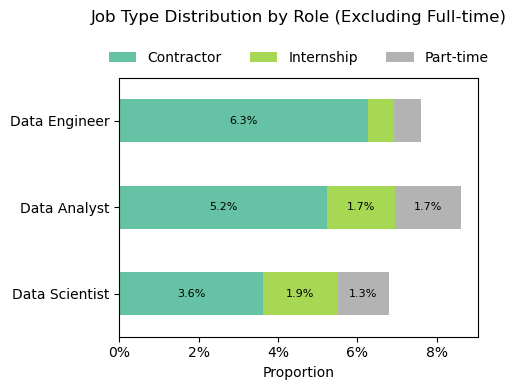

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

role_jobtype_filtered = role_jobtype_filtered.sort_values(by='Contractor', ascending=False)
ax = role_jobtype_filtered.plot(
    kind='barh',              # 👈 horizontal
    stacked=True,
    figsize=(5,4),
    colormap='Set2'
)

for i, row in enumerate(role_jobtype_filtered.values):
    cumulative = 0
    for j, val in enumerate(row):
        if val > 0.01:  # avoid tiny clutter labels
            ax.text(
                cumulative + val/2,
                i,
                f"{val*100:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                color='black'
            )
        cumulative += val

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x*100)}%')
)
ax.invert_yaxis()

plt.title('Job Type Distribution by Role (Excluding Full-time)', pad=40)
plt.xlabel('Proportion')
plt.ylabel('')

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x*100)}%')
)

plt.legend(
    title='',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),  # 👈 adjust height if needed
    ncol=3,                      # 👈 horizontal layout
    frameon=False
)

plt.tight_layout()
plt.show()

## 2. Platform Analysis

2.1 Job Distribution by Platform and Role

LinkedIn dominates job postings across all roles, followed by secondary platforms like BeBee.

In [9]:
df_jobvia = df.explode('job_via')

In [10]:
top5_platforms = df_jobvia['job_via'].value_counts().head(5)#.plot(kind='barh',title='Top 5 Job Platforms by Number of Postings')
top5_platforms.index

Index(['LinkedIn', 'BeBee', 'Trabajo.org', 'Indeed', 'Recruit.net'], dtype='str', name='job_via')

In [11]:
top_platforms = (
    df_jobvia.groupby(['job_title_short','job_via'])
    .size()
    .reset_index(name='count')
    .sort_values(['job_title_short', 'count'], ascending=[True, False])
)
top_platforms

,job_title_short,job_via,count
1052,Business Analyst,LinkedIn,8619
125,Business Analyst,BeBee,7526
1613,Business Analyst,Trabajo.org,5307
703,Business Analyst,Indeed,1767
1796,Business Analyst,ZipRecruiter,1352
...,...,...,...
19957,Software Engineer,キャリアクロス,1
19960,Software Engineer,台湾職缺 - Jooble,1
19964,Software Engineer,日経転職版 - 日本経済新聞,1
19965,Software Engineer,転職会議,1


In [12]:
top_platforms_per_role = top_platforms.groupby(['job_title_short','job_via']).first().sort_values(['count'], ascending=([False]))#.head(10) #.plot(kind='bar')
top_platforms_per_role

count
job_title_short       job_via                            
Data Engineer         LinkedIn                      58784
Data Analyst          LinkedIn                      41750
Data Scientist        LinkedIn                      37445
                      BeBee                         26590
Data Analyst          BeBee                         25756
...                                                   ...
                      Jobagent.ch                       1
Software Engineer     Фреш-Джоб                         1
                      Работа В Узбекистане              1
                      Работа В Таразе - HeadHunter      1
Senior Data Scientist The Home Depot - Talentify        1

[19972 rows x 1 columns]

In [13]:
top5_platforms_per_role = top_platforms_per_role.pivot_table(values='count',index='job_title_short',columns='job_via')
top5_platforms_per_role

job_via,- Career Associated,- The Intersect Group,1/ST Technology | Careers Center - ICIMS,10 Chambers,100000jobs.ch,100Hires.com,104人力銀行,1111人力銀行,123work,1840 & Company,...,인디드,자소설닷컴,잡플래닛,채용 - Jooble,채용공고 검색 엔진 | SimplyHired,캐치,프로그래머스 커리어,피플앤잡,하이브레인넷,🇩‌🇮‌🇸‌🇶‌🇦‌🇻‌🇦‌🇩‌ – Discover English Speaking Jobs In Germany
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,4.0,NaN,NaN,NaN,NaN,1.0,24.0,4.0,NaN,NaN,...,7.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
Cloud Engineer,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,...,6.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
Data Analyst,12.0,NaN,NaN,NaN,NaN,NaN,42.0,25.0,3.0,2.0,...,57.0,NaN,NaN,1.0,NaN,6.0,1.0,18.0,1.0,NaN
Data Engineer,7.0,1.0,1.0,NaN,1.0,NaN,52.0,32.0,NaN,NaN,...,80.0,NaN,1.0,3.0,2.0,8.0,7.0,9.0,NaN,NaN
Data Scientist,7.0,NaN,NaN,NaN,NaN,NaN,39.0,15.0,NaN,3.0,...,75.0,1.0,NaN,2.0,5.0,17.0,5.0,20.0,1.0,2.0
Machine Learning Engineer,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,NaN,NaN,...,9.0,NaN,NaN,2.0,1.0,NaN,3.0,NaN,NaN,NaN
Senior Data Analyst,4.0,NaN,NaN,NaN,1.0,NaN,3.0,2.0,NaN,NaN,...,4.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,NaN,NaN
Senior Data Engineer,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
Senior Data Scientist,NaN,NaN,NaN,1.0,NaN,NaN,6.0,1.0,NaN,NaN,...,4.0,NaN,NaN,1.0,NaN,NaN,NaN,4.0,NaN,NaN


In [14]:
top5_platforms_per_role = top5_platforms_per_role[top5_platforms.index]
top5_platforms_per_role

job_via,LinkedIn,BeBee,Trabajo.org,Indeed,Recruit.net
job_title_short,,,,,
Business Analyst,8619.0,7526.0,5307.0,1767.0,1327.0
Cloud Engineer,1247.0,2758.0,1958.0,132.0,444.0
Data Analyst,41750.0,25756.0,15477.0,12929.0,5949.0
Data Engineer,58784.0,18005.0,9054.0,11259.0,5118.0
Data Scientist,37445.0,26590.0,13617.0,10079.0,4921.0
Machine Learning Engineer,3003.0,1990.0,1210.0,518.0,522.0
Senior Data Analyst,6801.0,3512.0,2566.0,1443.0,1007.0
Senior Data Engineer,14907.0,3557.0,2084.0,2235.0,1239.0
Senior Data Scientist,8881.0,5217.0,3110.0,1732.0,1186.0


In [15]:
top5_platforms_per_top_roles = top5_platforms_per_role.loc[top_roles]
top5_platforms_per_top_roles

job_via,LinkedIn,BeBee,Trabajo.org,Indeed,Recruit.net
job_title_short,,,,,
Data Analyst,41750.0,25756.0,15477.0,12929.0,5949.0
Data Engineer,58784.0,18005.0,9054.0,11259.0,5118.0
Data Scientist,37445.0,26590.0,13617.0,10079.0,4921.0


In [16]:
pivot = top5_platforms_per_top_roles.div(
    top5_platforms_per_top_roles.sum(axis=1), axis=0
)
pivot

job_via,LinkedIn,BeBee,Trabajo.org,Indeed,Recruit.net
job_title_short,,,,,
Data Analyst,0.409872,0.252854,0.151942,0.126928,0.058403
Data Engineer,0.575073,0.176140,0.088574,0.110145,0.050068
Data Scientist,0.404147,0.286988,0.146969,0.108783,0.053113


In [17]:
pivot_long = pivot.reset_index().melt(
    id_vars='job_title_short',
    var_name='job_via',
    value_name='percentage'
)
pivot_long

,job_title_short,job_via,percentage
0,Data Analyst,LinkedIn,0.409872
1,Data Engineer,LinkedIn,0.575073
2,Data Scientist,LinkedIn,0.404147
3,Data Analyst,BeBee,0.252854
4,Data Engineer,BeBee,0.176140
5,Data Scientist,BeBee,0.286988
6,Data Analyst,Trabajo.org,0.151942
7,Data Engineer,Trabajo.org,0.088574
8,Data Scientist,Trabajo.org,0.146969
9,Data Analyst,Indeed,0.126928


In [18]:
order = pivot_long.groupby('job_title_short')['percentage'] \
    .sum().sort_values(ascending=False).index

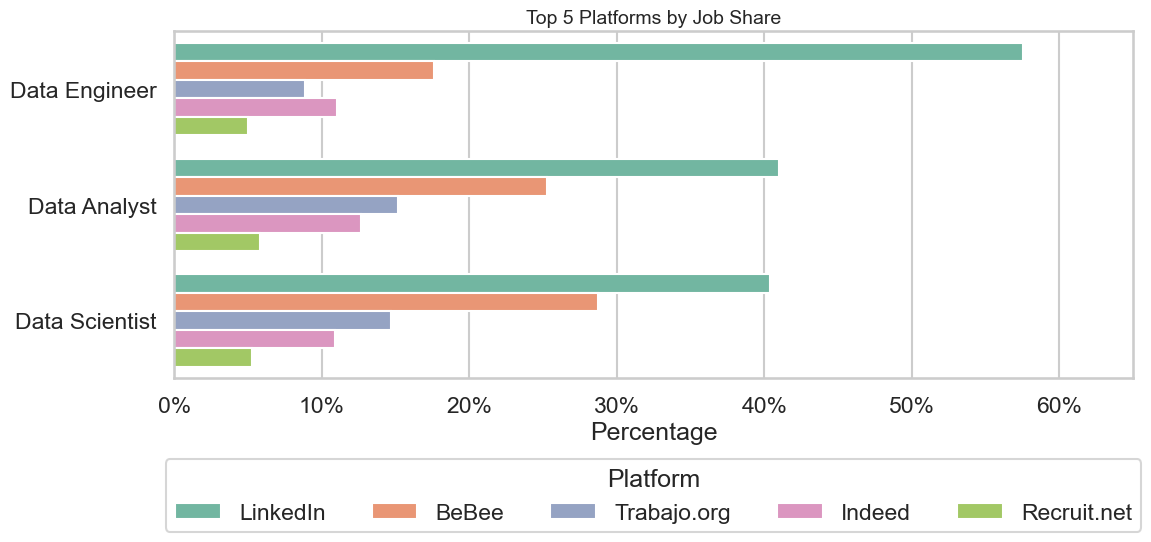

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

plt.figure(figsize=(12, 6))

order = (
    pivot_long[pivot_long['job_via'] == 'LinkedIn']
    .sort_values('percentage', ascending=False)['job_title_short']
)

hue_order = ['LinkedIn', 'BeBee', 'Trabajo.org', 'Indeed', 'Recruit.net']

sns.barplot(
    data=pivot_long,
    y='job_title_short',
    x='percentage',
    hue='job_via',
    order=order
)

plt.title('Top 5 Platforms by Job Share', fontsize=14)
plt.xlabel('Percentage')
plt.ylabel('')

plt.xlim(0, 0.65)
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x*100:.0f}%')

plt.legend(
    title='Platform',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=5
)

plt.tight_layout()
plt.show()

## 3. Remote vs On-site Analysis

3.1 Remote vs On-site Salary Comparison

Remote roles offer higher average salaries compared to on-site positions.

In [20]:
remote_salary = df.groupby('job_work_from_home')['salary_year_avg'].median()
remote_salary

job_work_from_home
False    115000.0000
True     128914.8125
Name: salary_year_avg, dtype: float64

In [21]:
df.groupby('job_work_from_home').count()

,job_title_short,job_title,job_location,job_via,job_schedule_type,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_id
job_work_from_home,,,,,,,,,,,,,,,,,
False,715362,715361,714317,715362,704005,715362,715362,715362,715362,715328,26996,18719,7970,715345,715362,715362,715362
True,69506,69506,69506,69506,68208,69506,69506,69506,69506,69491,6064,3278,2688,69505,69506,69506,69506


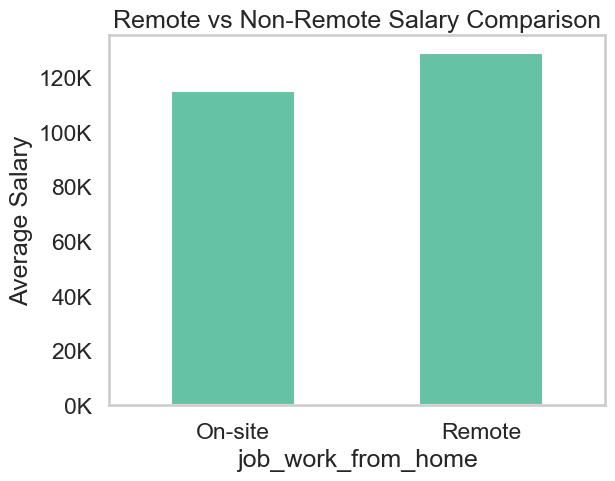

In [56]:
from matplotlib.ticker import FuncFormatter

remote_salary.plot(kind='bar')
plt.title('Remote vs Non-Remote Salary Comparison')
plt.ylabel('Average Salary')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.xticks([0,1], ['On-site', 'Remote'], rotation=0)
plt.grid(False)
plt.show()

3.2 Remote Work Trend Over Time
Job Demand vs Remote Share

Hiring demand and remote work trends move together, suggesting seasonal effects in the job market.
Remote work share fluctuates over time, with noticeable dips during periods of lower hiring activity.

In [60]:
df_roles = df[df['job_title_short'].isin(top_roles)]

In [61]:
df_roles['month'] = pd.to_datetime(df_roles['job_posted_date']).dt.to_period('M')
jobs_role_trend = (
    df_roles
    .groupby(['month', 'job_title_short'])
    .size()
    .unstack()
).copy()
jobs_role_trend

job_title_short,Data Analyst,Data Engineer,Data Scientist
month,,,
2023-01,23568,21391,20736
2023-02,16541,15882,13942
2023-03,16231,16081,13561
2023-04,15496,14877,13501
2023-05,13413,13635,11735
2023-06,15994,15487,13606
2023-07,16083,14493,14161
2023-08,18587,15592,16959
2023-09,14948,14890,13567


In [62]:
remote_role_trend = (
    df_roles
    .groupby(['month', 'job_title_short'])['job_work_from_home']
    .mean()
    .unstack()
)
remote_role_trend

job_title_short,Data Analyst,Data Engineer,Data Scientist
month,,,
2023-01,0.067295,0.093638,0.085696
2023-02,0.061786,0.104458,0.082054
2023-03,0.064629,0.109632,0.082737
2023-04,0.059499,0.094239,0.073476
2023-05,0.066354,0.110231,0.085471
2023-06,0.066713,0.109640,0.086873
2023-07,0.065286,0.114193,0.085940
2023-08,0.045838,0.087288,0.055605
2023-09,0.077602,0.134587,0.092430


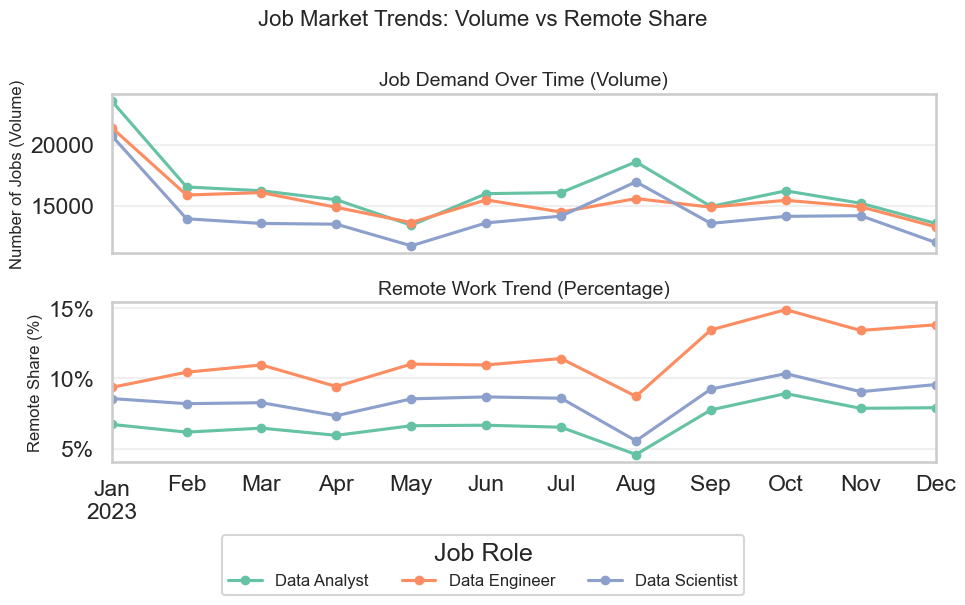

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

fig, axes = plt.subplots(2, 1, figsize=(10,6), sharex=True)
fig.suptitle('Job Market Trends: Volume vs Remote Share', fontsize=16)

# ---------------------------
# 1. Job postings
# ---------------------------
jobs_role_trend.plot(ax=axes[0], marker='o', markersize=6)

axes[0].set_title('Job Demand Over Time (Volume)',fontsize=14)
axes[0].set_ylabel('Number of Jobs (Volume)', fontsize=12)
axes[0].legend(title='Role', bbox_to_anchor=(1.05, 1))


# ---------------------------
# 2. Remote %
# ---------------------------
remote_role_trend.plot(ax=axes[1], marker='o', markersize=6)

axes[1].set_title('Remote Work Trend (Percentage)',fontsize=14)
axes[1].set_ylabel('Remote Share (%)',fontsize=12)
axes[1].set_xlabel('')

# Convert to %
axes[1].yaxis.set_major_formatter(lambda x, _: f'{x*100:.0f}%')

axes[1].legend(title='Role', bbox_to_anchor=(1.05, 1))

axes[0].legend().remove()
axes[1].legend().remove()

axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Job Role',
    fontsize=12,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=3
)


plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [24]:
# remote_platform = df_jobvia.groupby('job_via')['job_work_from_home'].mean().sort_values(ascending=False)
# remote_platform.head(10)

3.4 Platform-wise Remote vs On-site Gap

Different platforms show significant variation in remote work availability, indicating platform choice impacts job flexibility.

In [25]:
platform_counts = df_jobvia['job_via'].value_counts()
platform_counts

job_via
LinkedIn                186534
BeBee                   103406
Trabajo.org              61490
Indeed                   42712
Recruit.net              23636
                         ...  
melalui KHON2 Jobs           1
melalui Startup Jobs         1
melalui Melga                1
melalui Ricebowl             1
melalui Trigyn               1
Name: count, Length: 7903, dtype: int64

In [26]:
valid_platforms = platform_counts[platform_counts > 200].index
valid_platforms

Index(['LinkedIn', 'BeBee', 'Trabajo.org', 'Indeed', 'Recruit.net',
       'ZipRecruiter', 'Jobs Trabajo.org', 'Snagajob',
       'Trabajo.org - Vacantes De Empleo, Trabajo', 'BeBee India',
       ...
       'Learn4Good.com', 'Boston Consulting Group', 'Snowflake Careers',
       'JobiJoba.de', 'Indeed 台灣', 'Monster.fr', 'UNjobnet',
       'LinkedIn Armenia', 'Star Job Search', 'Indeed Argentina'],
      dtype='str', name='job_via', length=203)

In [27]:
remote_platform = (
    df_jobvia[df_jobvia['job_via'].isin(valid_platforms)]
    .groupby('job_via')['job_work_from_home']
    .mean()
    .sort_values(ascending=False)
)

remote_platform.head(10)

job_via
Upwork              1.000000
VentureLoop         1.000000
Jobgether           1.000000
JobTeaser           0.958929
Get.It              0.813910
LinkedIn Armenia    0.582090
IrishJobs.ie        0.463074
Totaljobs           0.438580
AngelList           0.397500
HelloWork           0.394052
Name: job_work_from_home, dtype: float64

In [28]:
remote_platform_pct = remote_platform * 100
remote_platform_pct.head(10)

job_via
Upwork              100.000000
VentureLoop         100.000000
Jobgether           100.000000
JobTeaser            95.892857
Get.It               81.390977
LinkedIn Armenia     58.208955
IrishJobs.ie         46.307385
Totaljobs            43.857965
AngelList            39.750000
HelloWork            39.405204
Name: job_work_from_home, dtype: float64

In [29]:
platform_df = remote_platform_pct.head(10).reset_index()
platform_df.columns = ['Platform', 'Remote_Percentage']
platform_df = platform_df.sort_values('Remote_Percentage')
platform_df['Non_Remote'] = 100 - platform_df['Remote_Percentage']
platform_df

,Platform,Remote_Percentage,Non_Remote
9,HelloWork,39.405204,60.594796
8,AngelList,39.750000,60.250000
7,Totaljobs,43.857965,56.142035
6,IrishJobs.ie,46.307385,53.692615
5,LinkedIn Armenia,58.208955,41.791045
4,Get.It,81.390977,18.609023
3,JobTeaser,95.892857,4.107143
2,Jobgether,100.000000,0.000000
1,VentureLoop,100.000000,0.000000
0,Upwork,100.000000,0.000000


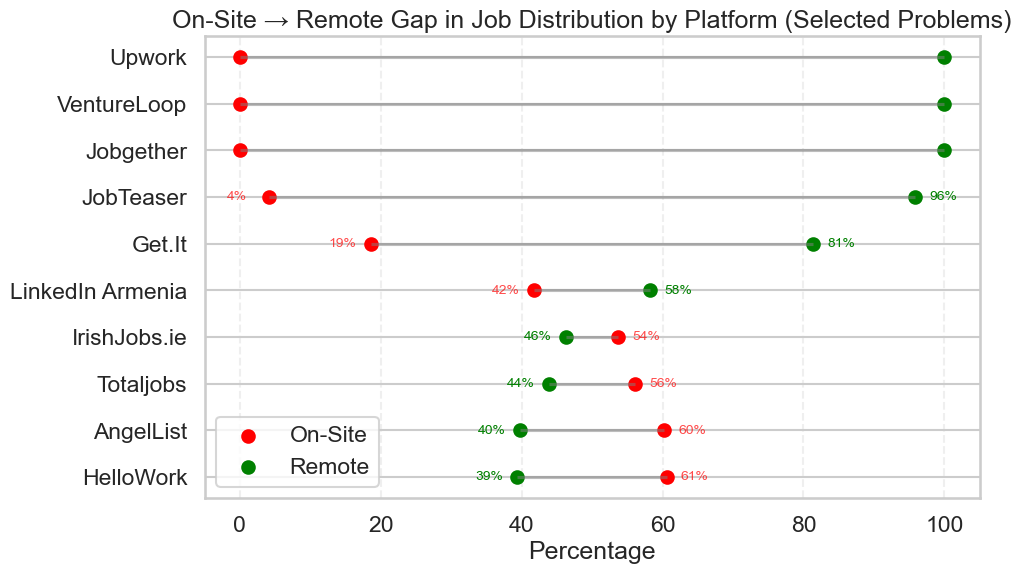

In [59]:
plt.figure(figsize=(10,6))

# Draw lines
plt.hlines(
    y=platform_df['Platform'],
    xmin=platform_df['Non_Remote'],
    xmax=platform_df['Remote_Percentage'],
    color='gray',
    alpha=0.5
)

# Plot points
plt.scatter(platform_df['Non_Remote'], platform_df['Platform'], color='red', label='On-Site')
plt.scatter(platform_df['Remote_Percentage'], platform_df['Platform'], color='green', label='Remote')

# for i, val in enumerate(platform_df['Remote_Percentage']):
#     plt.text(val + 1.5, i, f"{val:.0f}%", va='center', fontsize=10)

for i, (remote, non_remote) in enumerate(
    zip(platform_df['Remote_Percentage'], platform_df['Non_Remote'])
):
    if non_remote > 0:

        if remote > non_remote:

    # Remote label (right side)
            plt.text(remote + 2, i, f"{remote:.0f}%", va='center', fontsize=10, color='green')

    
    # Non-remote label (left side)
            plt.text(non_remote - 6 , i, f"{non_remote:.0f}%", va='center', fontsize=10, color='red', alpha=0.7)
        else:
             plt.text(remote - 6, i, f"{remote:.0f}%", va='center', fontsize=10, color='green')
             plt.text(non_remote + 2, i, f"{non_remote:.0f}%", va='center', fontsize=10, color='red', alpha=0.7)

    
plt.grid(axis='x', linestyle='--', alpha=0.3)
#plt.axvline(x=50, linestyle='--', color='gray', alpha=0.3)
plt.title('On-Site → Remote Gap in Job Distribution by Platform (Selected Problems)')
plt.xlabel('Percentage')
plt.legend()

plt.show()

In [ ]:
# “Different platform subsets are used to highlight specific insights:
# Top platforms for distribution vs selected platforms for remote-work comparison.”

3.5 Salary vs Demand vs Remote (Role Comparison)

Roles with higher demand and salaries also tend to offer more remote opportunities, especially for senior positions.

In [35]:
role_scatter = df.groupby('job_title_short').agg({
    'salary_year_avg': 'mean',
    'job_work_from_home': 'mean',
    'job_title_short': 'count'   # count = demand
}).rename(columns={'job_title_short': 'job_count'}).reset_index()
role_scatter

,job_title_short,salary_year_avg,job_work_from_home,job_count
0,Business Analyst,91082.612833,0.056901,49015
1,Cloud Engineer,111268.453846,0.046340,12322
2,Data Analyst,93837.359753,0.067997,195862
3,Data Engineer,130125.604250,0.113931,185999
4,Data Scientist,135992.381984,0.084431,172116
5,Machine Learning Engineer,126774.315972,0.105757,14070
6,Senior Data Analyst,113911.363665,0.080256,29194
7,Senior Data Engineer,145840.611624,0.147122,44521
8,Senior Data Scientist,154206.292996,0.102770,36937
9,Software Engineer,113393.760054,0.065310,44832


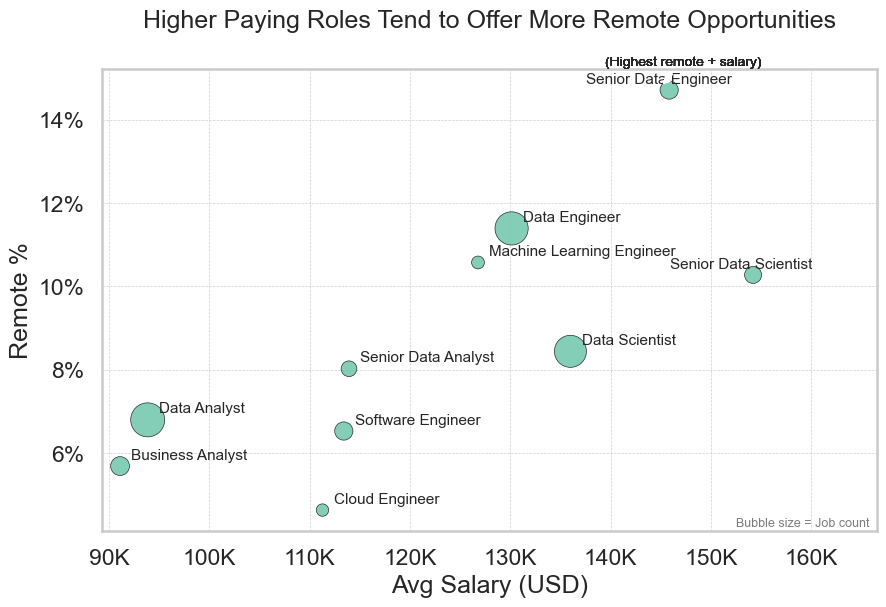

In [87]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=role_scatter,
    x='salary_year_avg',
    y='job_work_from_home',
    size='job_count',     # 👈 key addition
    sizes=(80, 600),     # control bubble size
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

# Remove legend
plt.legend([], [], frameon=False)

# Labels
# for i in range(len(role_scatter)):
#     plt.text(
#         role_scatter['salary_year_avg'][i] + 1000,
#         role_scatter['job_work_from_home'][i],
#         role_scatter['job_title_short'][i],
#         fontsize=9
#     )

# for i in range(len(role_scatter)):
#     plt.annotate(
#         role_scatter['job_title_short'][i],
#         (role_scatter['salary_year_avg'][i],
#          role_scatter['job_work_from_home'][i]),
#         textcoords="offset points",
#         xytext=(8, 5),   # 👈 spacing (x, y)
#         fontsize=11,
#         fontweight='medium'
#     )

for i in range(len(role_scatter)):
    x = role_scatter['salary_year_avg'][i]
    y = role_scatter['job_work_from_home'][i]
    label = role_scatter['job_title_short'][i]

    # adjust offset for edge points
    if x > 140000:
        offset = (-60, 5)   # move left
    else:
        offset = (8, 5)

    plt.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=offset,
        fontsize=11,
        fontweight='medium'
        #bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )

    plt.annotate(
        '(Highest remote + salary)',
        (145000, 0.148),
        textcoords="offset points",
        xytext=(-40, 15),
        fontsize=10,
        arrowprops=dict(arrowstyle='->', lw=1)
    )

plt.title('Higher Paying Roles Tend to Offer More Remote Opportunities', pad=30)
plt.xlabel('Avg Salary (USD)')
plt.ylabel('Remote %')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
plt.text(
    0.99, 0.01,
    'Bubble size = Job count',
    transform=plt.gca().transAxes,
    ha='right',
    fontsize=9,
    alpha=0.6
)

plt.gca().xaxis.set_major_formatter(lambda x, _: f'{int(x/1000)}K')
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x*100:.0f}%')

plt.xlim(
    role_scatter['salary_year_avg'].min() * 0.98,
    role_scatter['salary_year_avg'].max() * 1.08
)

plt.show()

- Full-time roles dominate the job market (>90%)
- LinkedIn is the primary hiring platform across roles
- Remote jobs offer higher salaries (~10–15% more)
- Hiring demand and remote share both dip mid-year (seasonality)
- Platform choice strongly affects remote job availability